# Kalshi Prediction Markets: Regulated Event Contracts

**Chapter 4: Fundamental and Alternative Data**
**Docker image**: `ml4t`
**Section Reference**: Section 4.4 (Understanding Alternative Data)

## Purpose

A prediction market contract pays one dollar if a stated event happens and nothing if it does
not. Its price is therefore a probability, quoted directly, with no model in between: a contract
on "the federal funds rate is above four and a quarter percent at the April 2027 meeting"
trading at fourteen cents is a fourteen percent chance, priced by people with money at stake.

Kalshi is the first such exchange the Commodity Futures Trading Commission has designated in the
United States, which makes it a legal venue rather than an offshore one and puts its data in
reach of an institutional research pipeline. This notebook reads its Federal Reserve rate
contracts, repairs the ingestion artifacts a thinly traded feed produces, checks the one
arbitrage relation the contracts have to satisfy, and measures whether there is enough trading
behind the prices to build a feature on.

## Learning Objectives

After completing this notebook, you will be able to:

- Read a binary event contract's price as a probability, and decode a ticker into the event it
  settles on.
- Detect the ingestion artifacts a carry-forward feed produces, and repair them without letting
  a repair introduce information from the future.
- Read a family of contracts on the same event at different thresholds as a distribution, and
  check the monotonicity that distribution has to satisfy.
- Measure the trading behind a quoted price, and distinguish a price that moved from a price
  that was carried.
- Build the probability features a rate-sensitive strategy would use, and say what the sample
  supports.

## Prerequisites

```bash
python data/prediction_markets/download.py
```

## Cross-References

- **Upstream**: `data/prediction_markets/download.py`
- **Related**: [`13_polymarket_prediction_markets`](13_polymarket_prediction_markets.ipynb) (the unregulated, higher-volume alternative)

In [1]:
"""Kalshi Prediction Markets - build event probability indicators from regulated binary contracts."""

import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from data.prediction_markets.loader import load_kalshi
from utils.paths import get_output_dir
from utils.style import COLORS, show_plotly_with_alt

In [2]:
MOMENTUM_DAYS = 5  # window the change in implied probability is measured over
VOLATILITY_DAYS = 10  # window its standard deviation and z-score are measured over
CONFIDENT_PROBABILITY = 0.2  # a contract within this of zero or one is treated as settled

In [3]:
OUTPUT_DIR = get_output_dir(4, "kalshi")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. What a contract is

A Kalshi contract settles at one dollar or nothing, so its price sits between the two and is
read as the probability of the event. The tick is a cent, which sets the resolution of that
probability at one percentage point.

**What this feed carries is the bid, not a mid or a trade.** The downloader takes
`yes_bid` - the highest price anyone is currently offering to pay for the YES side - so every
price below is a lower bound on what the market thinks, short by whatever the spread is. On a
liquid contract that is a cent; on the contracts here, where days pass without a trade, it can
be a great deal more, and nothing in the file says how much.

| Property | Value |
|----------|-------|
| Regulator | Commodity Futures Trading Commission |
| Settlement | US dollars |
| Position limit | Twenty-five thousand dollars per contract |
| Trading hours | Continuous |
| Minimum tick | One cent |

### Reading a ticker

`KXFED-27APR-T4.25` names three things: `KXFED` is the federal funds rate series, `27APR` is the
April 2027 meeting of the Federal Open Market Committee, and `T4.25` is the threshold. The
contract pays if the rate is **above** four and a quarter percent after that meeting, so its
price is the market's probability of that.

The threshold is what makes the series interesting. One contract gives one probability; a
ladder of thresholds on the same meeting gives the whole distribution, which Part 4 draws.

## 2. The data, and how much trading is behind it

The first three numbers to establish are how many bars there are, how many of them recorded a
trade, and how many recorded a change in price. On a market this young those are very different
numbers, and everything after depends on which one a statistic is really counting.

In [4]:
raw = load_kalshi()
print(f"Bars: {len(raw):,} across {raw['symbol'].n_unique()} contracts")
print(f"Dates: {raw['timestamp'].min()} to {raw['timestamp'].max()}")
print(f"Bars recording a trade: {int((raw['volume'] > 0).sum())}")
print(f"Contracts traded in the whole sample: {raw['volume'].sum():,.0f}")
raw.head(5)

Bars: 687 across 9 contracts
Dates: 2025-10-07 to 2025-12-31
Bars recording a trade: 5
Contracts traded in the whole sample: 315


timestamp,symbol,open,high,low,close,volume,category
date,str,f64,f64,f64,f64,f64,str
2025-10-20,"""KXFED-27APR-T0.25""",0.43,0.93,0.0,0.93,0.0,"""monetary_policy"""
2025-10-21,"""KXFED-27APR-T0.25""",0.93,0.93,0.93,0.93,0.0,"""monetary_policy"""
2025-10-22,"""KXFED-27APR-T0.25""",0.93,0.93,0.93,0.93,0.0,"""monetary_policy"""
2025-10-23,"""KXFED-27APR-T0.25""",0.93,0.93,0.01,0.92,0.0,"""monetary_policy"""
2025-10-24,"""KXFED-27APR-T0.25""",0.92,0.92,0.92,0.92,0.0,"""monetary_policy"""


Five traded bars out of several hundred is the fact that governs the rest of the notebook. The
price on every other bar is a quote carried forward, which is a real number - somebody is
willing to trade there - and is not a transaction.

### The artifacts a carry-forward feed produces

Two problems follow from the thinness, and both have to be dealt with before anything is
computed.

A price field of exactly zero alongside a positive high is an ingestion artifact. A live
contract trades strictly inside zero and one, and one that closes near ninety cents cannot have
printed a true zero the same day. Left in, a single such bar makes a pinned contract look like
the widest-ranging one in the universe.

On a bar with no volume there is also no intraday range: the high and the low are carried from
whenever the contract last traded, so the distance between them measures the age of the quote
rather than the day's uncertainty. The close is the only field worth keeping on such a bar.

In [5]:
suspect = (pl.col("high") > 0.0) & (
    (pl.col("open") == 0.0) | (pl.col("low") == 0.0) | (pl.col("close") == 0.0)
)
artifacts = raw.filter(suspect).select(
    "timestamp", "symbol", "open", "high", "low", "close", "volume"
)
print(f"Bars with a zero price field alongside a positive high: {len(artifacts)}")
artifacts.head(8)

Bars with a zero price field alongside a positive high: 35


timestamp,symbol,open,high,low,close,volume
date,str,f64,f64,f64,f64,f64
2025-10-20,"""KXFED-27APR-T0.25""",0.43,0.93,0.0,0.93,0.0
2025-10-25,"""KXFED-27APR-T0.25""",0.92,0.92,0.0,0.92,0.0
2025-10-20,"""KXFED-27APR-T2.25""",0.43,0.75,0.0,0.75,0.0
2025-10-25,"""KXFED-27APR-T2.25""",0.73,0.73,0.0,0.73,0.0
2025-10-20,"""KXFED-27APR-T3.75""",0.43,0.46,0.0,0.14,0.0
2025-10-25,"""KXFED-27APR-T3.75""",0.12,0.12,0.0,0.11,0.0
2025-10-20,"""KXFED-27APR-T4.00""",0.43,0.46,0.0,0.06,0.0
2025-10-25,"""KXFED-27APR-T4.00""",0.04,0.04,0.0,0.04,0.0


In [6]:
traded = pl.col("volume") > 0
kalshi = (
    raw.sort("symbol", "timestamp")
    .with_columns(
        # Null the impossible closes, then carry the last real one forward. Only forward:
        # a backward fill would put a later price on an earlier date, which is the exact
        # look-ahead this chapter exists to prevent, and it is invisible once done.
        pl.when((pl.col("close") == 0.0) & (pl.col("high") > 0.0))
        .then(None)
        .otherwise(pl.col("close"))
        .alias("close")
    )
    .with_columns(pl.col("close").forward_fill().over("symbol"))
    .with_columns(
        # A bar that did not trade is a flat snapshot at its close, not a range.
        pl.when(traded).then(pl.col("open")).otherwise(pl.col("close")).alias("open"),
        pl.when(traded).then(pl.col("high")).otherwise(pl.col("close")).alias("high"),
        pl.when(traded).then(pl.col("low")).otherwise(pl.col("close")).alias("low"),
    )
)
print(f"Bars with no usable close after the repair: {kalshi['close'].null_count()}")
print(
    f"Prices still outside the zero-to-one range: {kalshi.filter((pl.col('close') < 0) | (pl.col('close') > 1)).height}"
)

Bars with no usable close after the repair: 0
Prices still outside the zero-to-one range: 0


## 3. The contract universe

With the artifacts out, each contract can be summarized by where its probability started and
ended, how often that probability changed at all, and how often it changed because somebody
traded.

In [7]:
summary = (
    kalshi.sort("timestamp")
    .group_by("symbol")
    .agg(
        pl.col("close").first().alias("first_probability"),
        pl.col("close").last().alias("last_probability"),
        (pl.col("close").max() - pl.col("close").min()).alias("probability_range"),
        pl.col("close").diff().ne(0).sum().alias("days_the_price_moved"),
        (pl.col("volume") > 0).sum().alias("days_traded"),
        pl.len().alias("bars"),
    )
    .sort("probability_range", descending=True)
)
summary

symbol,first_probability,last_probability,probability_range,days_the_price_moved,days_traded,bars
str,f64,f64,f64,u32,u32,u32
"""KXFED-27JAN-T3.00""",0.61,0.39,0.23,15,3,86
"""KXFED-27JAN-T1.00""",0.89,0.95,0.08,7,0,86
"""KXFED-27MAR-T2.75""",0.59,0.51,0.08,8,0,78
"""KXFED-27APR-T3.75""",0.14,0.14,0.04,5,1,73
"""KXFED-27APR-T2.25""",0.75,0.74,0.03,5,0,73
"""KXFED-27APR-T4.00""",0.06,0.06,0.03,4,0,73
"""KXFED-27MAR-T0.50""",0.96,0.95,0.02,6,1,78
"""KXFED-27APR-T0.25""",0.93,0.92,0.02,4,0,73
"""KXFED-27APR-T4.25""",0.01,0.01,0.01,2,0,67


The gap between the last two columns is the whole story of this dataset. Prices move far more
often than trades happen, because the quote is revised whether or not anyone crosses it. That
is not a defect - a revised quote carries information - but it fixes what a statistic computed
on this series is measuring, which is quote revisions and not trading.

## 4. A threshold ladder is a distribution

All the contracts here are on the federal funds rate, and several share a meeting at different
thresholds. Since each pays if the rate is *above* its threshold, reading a meeting's contracts
in threshold order gives the market's implied survival function for the rate: the probability of
exceeding each level.

That structure carries an ordering. A higher threshold is harder to exceed, so the market's
probability for it cannot exceed a lower threshold's.

Checking that ordering on these prices is a **diagnostic and not an arbitrage test**, because
the prices are bids. Two contracts with different spreads can show a higher threshold's bid
above a lower one while their midpoints are correctly ordered, and nothing is tradeable: an
arbitrage needs the higher threshold's bid against the lower threshold's ask, net of fees.

So a violation here says the bid ordering is broken and does not say why. Two spreads of
different widths and two quotes of different ages both produce it, and separating them needs
the ask side, which this feed does not carry. It is still worth running, because a feed that
never violates the ordering is one whose quotes move together, and that is a property to know
about before either price is used.

The downloader is configured for six Kalshi series and only the rate series uses the
meeting-and-threshold ticker shape, so the ladder is built from the contracts whose ticker
matches that shape rather than from everything loaded. A contract from another series reaches
the notebook as an unparsed row rather than as a crash or, worse, as a threshold read off the
wrong part of its name.

In [8]:
THRESHOLD_TICKER = r"^KXFED-(?<meeting>[0-9]{2}[A-Z]{3})-T(?<threshold>[0-9]+(?:\.[0-9]+)?)$"

# Select the threshold contracts first, then take their own latest date: taking the panel's
# latest date first would return nothing whenever another series traded more recently.
threshold_contracts = (
    kalshi.with_columns(parsed=pl.col("symbol").str.extract_groups(THRESHOLD_TICKER))
    .unnest("parsed")
    .drop_nulls("meeting")
    .with_columns(pl.col("threshold").cast(pl.Float64))
)
ladder = (
    threshold_contracts.filter(pl.col("timestamp") == threshold_contracts["timestamp"].max())
    .select("meeting", "threshold", "symbol", probability="close")
    .sort("meeting", "threshold")
    if not threshold_contracts.is_empty()
    else threshold_contracts.select("meeting", "threshold", "symbol", probability=pl.col("close"))
)
print(f"Contracts loaded: {kalshi['symbol'].n_unique()}")
print(f"Of those, rate-threshold contracts: {threshold_contracts['symbol'].n_unique()}")
violations = ladder.with_columns(rises=pl.col("probability").diff().over("meeting") > 0).filter(
    pl.col("rises")
)
print(f"Meetings with a threshold ladder: {ladder['meeting'].n_unique()}")
print(f"Places where a higher threshold's bid exceeds a lower threshold's: {len(violations)}")
ladder

Contracts loaded: 9
Of those, rate-threshold contracts: 9
Meetings with a threshold ladder: 3
Places where a higher threshold's bid exceeds a lower threshold's: 0


meeting,threshold,symbol,probability
str,f64,str,f64
"""27APR""",0.25,"""KXFED-27APR-T0.25""",0.92
"""27APR""",2.25,"""KXFED-27APR-T2.25""",0.74
"""27APR""",3.75,"""KXFED-27APR-T3.75""",0.14
"""27APR""",4.0,"""KXFED-27APR-T4.00""",0.06
"""27APR""",4.25,"""KXFED-27APR-T4.25""",0.01
"""27JAN""",1.0,"""KXFED-27JAN-T1.00""",0.95
"""27JAN""",3.0,"""KXFED-27JAN-T3.00""",0.39
"""27MAR""",0.5,"""KXFED-27MAR-T0.50""",0.95
"""27MAR""",2.75,"""KXFED-27MAR-T2.75""",0.51


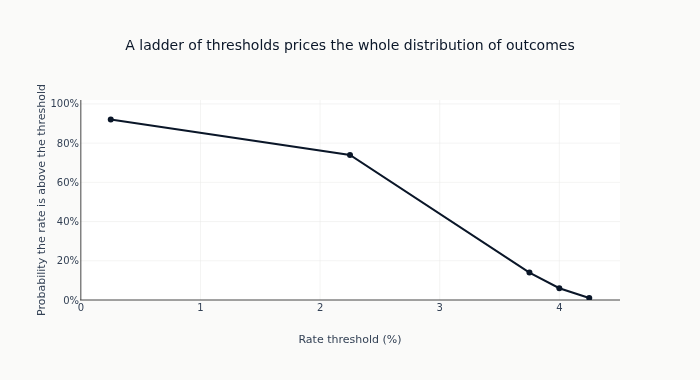

In [9]:
# Ties on contract count are broken by meeting label so the same meeting is drawn on every run.
widest_meeting = (
    ladder.group_by("meeting").len().sort(["len", "meeting"], descending=[True, False])["meeting"]
)
fig = px.line(
    ladder.filter(pl.col("meeting") == widest_meeting[0]).to_pandas()
    if len(widest_meeting)
    else ladder.to_pandas(),
    x="threshold",
    y="probability",
    markers=True,
    title="A ladder of thresholds prices the whole distribution of outcomes",
    labels={
        "threshold": "Rate threshold (%)",
        "probability": "Probability the rate is above the threshold",
    },
    color_discrete_sequence=[COLORS["blue"]],
)
fig.update_layout(height=380, yaxis_tickformat=".0%", yaxis_range=[0, 1.02])
show_plotly_with_alt(
    fig,
    "Line chart with markers of the probability the federal funds rate exceeds each traded "
    "threshold at one meeting, falling from near certainty at the lowest threshold to almost "
    "nothing at the highest, with the steepest fall between the middle two.",
)

The curve falls fastest between the thresholds the market thinks are live, which is where the
distribution has its mass. The difference between two adjacent points is roughly the
probability the rate lands between those two levels - roughly, because each point is a bid and
the difference of two bids carries both spreads.

## 5. How the probabilities moved

Over time, each contract's price traces the market's changing view. The contracts whose
thresholds sit near the expected rate move; the ones far above or below it stay pinned, because
no news plausibly changes their answer.

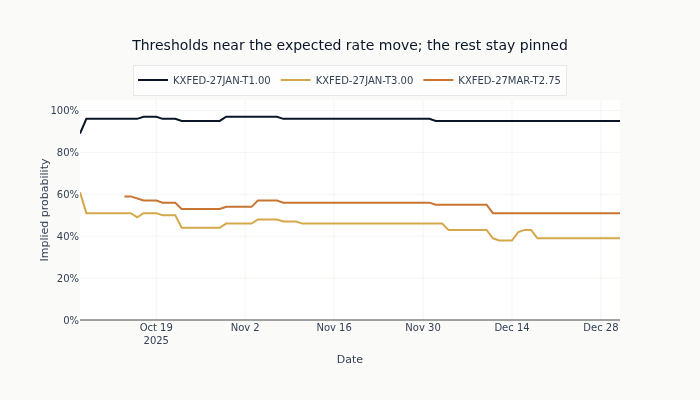

In [10]:
most_movement = summary.head(3)["symbol"].to_list()
paths = kalshi.filter(pl.col("symbol").is_in(most_movement)).sort("timestamp")

fig = px.line(
    paths.to_pandas(),
    x="timestamp",
    y="close",
    color="symbol",
    title="Thresholds near the expected rate move; the rest stay pinned",
    labels={"timestamp": "Date", "close": "Implied probability", "symbol": ""},
    color_discrete_sequence=[COLORS["blue"], COLORS["amber"], COLORS["copper"]],
)
fig.update_layout(
    height=400,
    yaxis_tickformat=".0%",
    yaxis_range=[0, 1.05],
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
)
show_plotly_with_alt(
    fig,
    "Line chart of the implied probability of the three contracts whose prices moved most, each "
    "a step function that holds a level for weeks and then jumps.",
)

Every path is a staircase rather than a curve, and that shape is the sample rather than the
market: with a handful of price revisions per contract over three months, the series is flat
between them by construction.

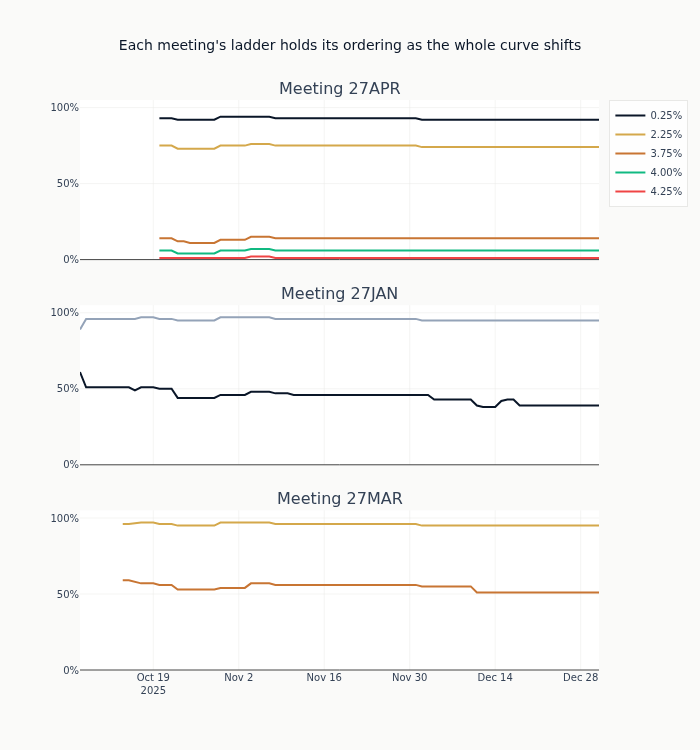

In [11]:
meetings = sorted(
    kalshi.with_columns(meeting=pl.col("symbol").str.split("-").list.get(1))["meeting"].unique()
)
fig = make_subplots(
    rows=len(meetings),
    cols=1,
    shared_xaxes=True,
    subplot_titles=[f"Meeting {m}" for m in meetings],
    vertical_spacing=0.08,
)
for row, meeting in enumerate(meetings, 1):
    for symbol in sorted(kalshi.filter(pl.col("symbol").str.contains(meeting))["symbol"].unique()):
        series = kalshi.filter(pl.col("symbol") == symbol).sort("timestamp")
        fig.add_trace(
            go.Scatter(
                x=series["timestamp"],
                y=series["close"],
                mode="lines",
                name=symbol.split("-T")[-1] + "%",
                showlegend=(row == 1),
            ),
            row=row,
            col=1,
        )
    fig.update_yaxes(tickformat=".0%", range=[0, 1.05], row=row, col=1)
fig.update_layout(
    height=250 * len(meetings),
    title_text="Each meeting's ladder holds its ordering as the whole curve shifts",
)
show_plotly_with_alt(
    fig,
    "One panel per Federal Open Market Committee meeting, each showing the implied probability "
    "path of every traded threshold for that meeting. Within each panel the lines keep their "
    "vertical ordering throughout.",
)

## 6. Features, and what this sample supports

The features a rate-sensitive strategy would take from this feed are the ones any probability
path suggests: how far it has moved recently, how variable those moves are, where it sits
against its own recent range, and whether it has settled near certainty.

The intraday range is deliberately not among them. After the repair, a non-traded bar has a high
and a low equal to its close, so a range feature would be zero on every bar except the five that
traded, and would be measuring the repair rather than the market.

In [12]:
features = kalshi.sort("symbol", "timestamp").with_columns(
    probability_change=(pl.col("close") - pl.col("close").shift(MOMENTUM_DAYS)).over("symbol"),
    probability_volatility=pl.col("close").diff().rolling_std(VOLATILITY_DAYS).over("symbol"),
    # A window in which the price never moved has no scale to standardize against, so the
    # z-score is undefined there. Substituting zero would read as "exactly at its average".
    probability_zscore=(
        pl.when(pl.col("close").rolling_std(VOLATILITY_DAYS) > 0)
        .then(
            (pl.col("close") - pl.col("close").rolling_mean(VOLATILITY_DAYS))
            / pl.col("close").rolling_std(VOLATILITY_DAYS)
        )
        .otherwise(None)
    ).over("symbol"),
    near_certain=(
        (pl.col("close") > 1 - CONFIDENT_PROBABILITY) | (pl.col("close") < CONFIDENT_PROBABILITY)
    ).cast(pl.Int8),
)

defined = features.select(
    pl.len().alias("bars"),
    pl.col("probability_change").is_not_null().sum().alias("change_defined"),
    (pl.col("probability_change") != 0).sum().alias("change_non_zero"),
    pl.col("probability_zscore").is_not_null().sum().alias("zscore_defined"),
)
defined

bars,change_defined,change_non_zero,zscore_defined
u32,u32,u32,u32
687,642,204,412


The last two columns are the measurement this section exists for. The momentum feature is
defined on most bars and non-zero on few of them, and the z-score is undefined wherever the
price held still for the whole window. A model fitted on these columns would be fitting a
handful of events dressed as a daily panel.

That is a statement about this snapshot and not about the method. The construction is the right
one and the feed will support it once the market is older; what a reader should take from the
table is the habit of counting how many of a feature's values are real before using it.

In [13]:
features.select(
    "timestamp",
    "symbol",
    "close",
    "probability_change",
    "probability_volatility",
    "probability_zscore",
    "near_certain",
).tail(8)

timestamp,symbol,close,probability_change,probability_volatility,probability_zscore,near_certain
date,str,f64,f64,f64,f64,i8
2025-12-24,"""KXFED-27MAR-T2.75""",0.51,0.0,0.0,null,0
2025-12-25,"""KXFED-27MAR-T2.75""",0.51,0.0,0.0,null,0
2025-12-26,"""KXFED-27MAR-T2.75""",0.51,0.0,0.0,null,0
2025-12-27,"""KXFED-27MAR-T2.75""",0.51,0.0,0.0,null,0
2025-12-28,"""KXFED-27MAR-T2.75""",0.51,0.0,0.0,null,0
2025-12-29,"""KXFED-27MAR-T2.75""",0.51,0.0,0.0,null,0
2025-12-30,"""KXFED-27MAR-T2.75""",0.51,0.0,0.0,null,0
2025-12-31,"""KXFED-27MAR-T2.75""",0.51,0.0,0.0,null,0


## 7. Saving the feature panel

In [14]:
output_file = OUTPUT_DIR / "kalshi_features.parquet"
features.write_parquet(output_file)
print(f"Wrote {len(features):,} rows to {output_file}")

Wrote 687 rows to ~/ml4t/public-teach-b/04_fundamental_alternative_data/output/kalshi/kalshi_features.parquet


## Key Takeaways

1. A binary contract's price is a probability with no model between the two, which is what makes
   a prediction market worth reading: every other forecast in a pipeline has to be calibrated,
   and this one is quoted. Check which price the feed carries, though. This one is the highest
   standing bid for the YES side, so it is short of the market's view by a spread that a thin
   book can make large.
2. A ladder of thresholds on the same event is a distribution, and its ordering is worth
   checking: a higher threshold's probability cannot exceed a lower one's. On bid prices that is
   a staleness diagnostic rather than an arbitrage test, since an arbitrage compares a bid
   against an ask.
3. Separate the bars that traded from the bars that were carried. A carried quote still holds
   information, but a statistic computed over both is measuring quote revisions, and a feature
   named for volume or for intraday range is measuring the carry.
4. Repair forward, never backward. Filling a leading gap from a later value puts tomorrow's
   price on today's date, and nothing downstream will show that it happened.
5. Count how many of a feature's values are real before fitting anything on it. A column that is
   defined on every row and non-zero on a handful is a panel in shape only.

**Next**: [`13_polymarket_prediction_markets`](13_polymarket_prediction_markets.ipynb) reads the
unregulated venue, where the volume is orders of magnitude larger and the trade-offs are
different.